**ML1-Notebook3**

***Author: Açelya Yıldırım***
***Date: 10.10.2025***

# Overfitting

One of the most important issues in Machine Learning is to understand the difference between training and testing errors. The training process will allow the ANN parameters (weights and bias) to be modified to minimise the loss in the **set of patterns used for training**.  If this set of patterns is sufficiently representative, then the ANN will perform well in its working environment, i.e. with new patterns that are not in the training set.  On the other hand, if this set of patterns has not been well chosen, the ANN could not work well with new patterns.  The only way to know this is precisely to evaluate the ANN with new patterns and calculate the error with these **test patterns**.  Since the test set is available from the beginning, this evaluation with the test set is done at the same time as with the training set (but only the training set is used for training). 

Therefore, to assess how well trained an ANN is, this can be done by evaluating the test set, not the training set.  Usually there is only one set of data, so it is usually divided into two subsets: training and test. There are several alternatives to perform this division; in these tutorials, two different ones will be performed: 

* **Hold Out**. In this method, an experiment is performed with a simple partition of the data set, leaving a certain percentage for testing, usually between 20% and 30%. 

* **Cross-validation**.  Here, the data set is divided into $k$ disjoint subsets in order to perform the corresponding $k$ experiments.  In the k-th experiment, the $k$-th set is separated for testing, and trained with the remaining $k-1$.  A usual value of $k$ is 10, so you have a 10-fold crossvalidation.

More specifically, in this session we will focus on the first one, leaving the second one for a later one.  The hold out technique allows us to split the data set into two subsets: training and test.  The training subset allows to adjust the parameters of the model (connection weights and bias), while the test subset allows to check (test) the behavious of a trained ANN (or, any kind of model that is being used, such as a decision tree) on new patterns, not present in the training set.

![Normal training in the left, and an overfitting curve on the right](./img/Overfitting.png)

Given a well-chosen (and therefore sufficiently representative) training set, the training process could be similar to the figure on the left, with both training and test errors decreasing with each cycle. However, in general, it cannot be ensured that the training set is as noise-free and well-chosen as desirable, so that **overtraining** or **overfitting** often occurs during training.  This can be clearly seen in the figure on the right, where both errors are decreasing until a point is reached where the test error starts to increase.   From that point on, the system starts to overfit. 

To avoid overfitting, in ANNs there are a series of techniques known as regularisation techniques, each of which is very different in nature, but all of which aim to avoid overtraining.  Although these techniques are dealt with in much greater depth in other subjects in the programme, e.g. Deep Learning I, in these tutorials we are going to study one of the most well-known techniques, seen in the theory session, called Early Stopping. 

In this technique, instead of dividing the initial set of samples into 2 subsets, we create 3 subsets: training, validation and test.  The training and test sets perform the functions described above. The purpose of the validation set is to avoid overfitting by controlling the training process, but it is not used to modify weights or bias.  There are several ways to control the training process, here we will use two of them together:

* A new criteria for stopping the training process.   With the definition of a new parameter: the maximum number of consecutive cycles without improving the *loss* in the validation set.  If these cycles elapse without improving the best validation *loss* achieved so far, the training is stopped.  As the validation set is not used to modify weights or bias, it gives an estimate of what the test error could be.  Therefore, when the validation error increases, it increases the error in patterns that it has not seen, so it is estimated that the test error would increase, and the network would be overtraining.


* Once the training process has stopped, the validation set determines which network is returned.  During all the training cycles, the loss is calculated in the training set, which is necessary to modify weights and bias, but also in the validation set.   Once the training is stopped, the ANN is returned corresponding not to the last cycle, but to the cycle with the lowest error in the validation set.  This is done because it is estimated that this ANN is the one that will give the lowest error in the test set, i.e. the one that will behave better with new patterns and, consequently, the one that will generalise better. 

Once the training process has stopped and an ANN has been returned, the test set can be evaluated to assess how well the ANN has been trained. 

> **Important**: The errors (or accuracies, or any metric used) in the training and validation sets are interesting, but the one that really matters is the test set. 

However, most of the time you have all 3 sets (training, validation and test) from the beginning, so as you evaluate the training and validation sets, you also evaluate the test set, which is useful for plotting graphs. However, these values in the test set cannot be used for decision making. 

### Question 3.1
> ❓ If what we want to achieve is an ANN with the lowest possible test error, why not choose the ANN corresponding to the cycle with the lowest test error?

Using the test set for cycle selection violates one of the fundamental principles of machine learning: that the test set be completely unbiased and isolated from the training process.

Main Reasons:

Data Leakage: If we use the test set for model selection or hyperparameter tuning, the model indirectly learns about the test data. This gives the model an advantage it doesn't actually have and makes its actual performance appear better than it actually is.

Loss of Unbiasedness: The test set is designed to measure the model's performance on data it has never seen. If we use the test set for training decisions, we lose this unbiasedness, and the performance metrics we obtain will not reflect real-world scenarios.

Overly Optimistic Evaluation: A low error obtained by chance on the test set may reflect the model's chance fit to that specific piece of data, not its true generalization ability. This leads to poor performance on new data we will encounter in practice.

The Role of the Validation Set: This is why we use a validation set. The validation set is a dataset that can be used for model selection and hyperparameter optimization, but is not directly involved in the training process. By selecting the cycle with the lowest validation loss, we obtain a reliable indication that the model can indeed generalize well.

Consequently, the test set should only be used at the end, after all training and model selection have been completed, to assess the model's true performance objectively. Otherwise, we will end up with models that appear successful but fail in practice.

Therefore, in the training loop it is necessary to keep a reference to the best validation error found so far.  It is also necessary to keep a copy of the ANN that has given that validation error.  Both elements should be updated every cycle when the validation error improves. It is also necessary to keep a counter of how many consecutive cycles the validation error has not improved.

As can be seen, the test set cannot have any involvement in the training process. This is the right thing to do, since an ANN with completely new patterns is being evaluated. However, from a very strict point of view, there is one part in this whole process where the test set is having a small influence: in the normalisation of the data.

Usually the starting point is a dataset that is first normalised and then split into training/test.  If this is done in this way, the patterns used for testing have some influence on the calculation of the normalisation parameter values, which would not be correct. However, the impact they usually have on these parameters and in general on the performance of the ANN is so low, that this is usually not taken into account and all patterns are normalised together.  In any case, the really correct pipeline to do would be divide the data into train test, to calculate the values of the normalisation parameters only with the training set, and the applied that parameters of normalization to the test prior to run the usual training process. Addtionally, if there is a validation data, it can be used on the normalization, too.

For this assignment, you are asked to perform two sets of experiments, one without using validation and the other using a validation set.  More specifically, the requirements are: 

1. Develop a function called `holdOut` that given two parameters, `N` (equal to the number of patterns) and `P` (value between 0 and 1, indicating the percentage of patterns that will be separated for the test set), returns a tuple with two vectors with the indices of the patterns that will be used for training and testing.  The sum of lengths of both vectors has to be equal to N, and these two vectors have to be disjoint.

  This function can be done in a very simple way using the function `randperm` (to use it, load the module with `using Random`).
  
  From this function, splitting a database into two subsets is done immediately.

In [11]:
using Random
using DataFrames, CSV
using Statistics

# Loading data
df = CSV.File("/Users/acelyaa.yildirimm/Desktop/iris/iris.data", header=false) |> DataFrame

features = Matrix(df[:, 1:4])
labels = df[:, 5]
labels_bool = labels .== "Iris-setosa"

println("Data loaded")
println("Total sample: ", length(labels))

# ============================================
# HOLDOUT FUNCTIONS
# ============================================

# 1. For two sets (Training and Testing)
function holdOut(N::Int, P::Real)
    @assert 0 <= P <= 1 "P must be between 0 and 1"
    @assert N > 0 "N must be positive"
    
    indices = randperm(N)
    test_size = round(Int, N * P)
    
    test_indices = indices[1:test_size]
    train_indices = indices[test_size+1:end]
    
    return (train_indices, test_indices)
end


Data loaded
Total sample: 150


holdOut (generic function with 1 method)

2. Develop another function called `holdOut`, the same as the previous one and, based on it, which takes 3 parameters: `N` (number of patterns), `Pval` (rate of patterns in the validation set) and `Ptest` (rate of patterns in the test set), and returns a tuple with 3 vectors, with the indices of the elements of the training, validation and test sets. The sum of the lengths of these 3 vectors has to be equal to `N`.

 To do this, simply make two calls to the previously developed `holdOut` function. 

In [13]:
# 2. For three sets (Training, Validation, Test)
function holdOut(N::Int, Pval::Real, Ptest::Real)
    @assert 0 <= Pval <= 1 "Pval must be between 0 and 1"
    @assert 0 <= Ptest <= 1 "Ptest must be between 0 and 1"
    @assert (Pval + Ptest) <= 1 "Pval + Ptest must be <= 1"
    @assert N > 0 "N must be positive"
    
    # Split the test set first
    train_val_indices, test_indices = holdOut(N, Ptest)
    
    # Set validation percentage
    adjusted_Pval = Pval * N / length(train_val_indices)
    
    # Separate training and validation
    train_indices, val_indices = holdOut(length(train_val_indices), adjusted_Pval)
    
    # Return to original indices
    train_indices = train_val_indices[train_indices]
    val_indices = train_val_indices[val_indices]
    
    return (train_indices, val_indices, test_indices)
end


holdOut (generic function with 2 methods)

In [17]:
N = size(features, 1)
Pval = 0.2  
Ptest = 0.1 

train_idx, val_idx, test_idx = holdOut(N, Pval, Ptest)

println("Dataset Split:")
println("  Training:   ", length(train_idx), " samples (", round(length(train_idx)/N*100, digits=1), "%)")
println("  Validation: ", length(val_idx), " samples (", round(length(val_idx)/N*100, digits=1), "%)")
println("  Test:       ", length(test_idx), " samples (", round(length(test_idx)/N*100, digits=1), "%)")

println("\nIntersection Check:")
println("  Train ∩ Val:  ", length(intersect(train_idx, val_idx)))
println("  Train ∩ Test: ", length(intersect(train_idx, test_idx)))
println("  Val ∩ Test:   ", length(intersect(val_idx, test_idx)))

Dataset Split:
  Training:   105 samples (70.0%)
  Validation: 30 samples (20.0%)
  Test:       15 samples (10.0%)

Intersection Check:
  Train ∩ Val:  0
  Train ∩ Test: 0
  Val ∩ Test:   0


The holdOut function successfully split the dataset into three disjoint subsets. Out of 150 samples, 105 (70%) were allocated to training, 30 (20%) to validation, and 15 (10%) to the test set. The intersection check confirms that all three sets are
completely disjoint with no overlapping samples, which is essential for preventing data leakage and ensuring unbiased model evaluation.

3. Modify the function for training the ANN developed in the previous session to accept the following *optional* parameters in addition to those defined in the previous practice:
  - **Validation set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **Test set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **maxEpochsVal**, of type `Int`, which defines the number of cycles without improving the best validation loss found so far that have to elapse to stop training. In other words, it defines a new stop criterion. Default value should be set to 20.
  
  With these parameters, this function should implement the early stopping strategy, for which it is necessary to take care that the ANN returned at the end of the function must be: 
    - If a validation set has been given as a argument (i.e. if it is not empty), the ANN to be returned does not have to be the one being trained, but the one with the best validation error.
    - If no validation set has been passed as a parameter (i.e. if it is empty), the ANN to be returned should be the one corresponding to the last training cycle.  Consequently, the new training function should work in the same way as the previous one in case no validation set is given.
    
  Additionally, from the trained ANN, this function should return a history of the loss values obtained in the training, validation and test sets in each cycle, as a vector each.
  
  - To add elements to the end of a vector, refer to the function `push!`
  - It should be noted that the loss values obtained with the ANN with random weights, prior to training, are usually considered as cycle 0. 
  
  As stated in the previous description, it will be necessary to store the best ANN achieved so far and update it in some iterations of the loop.  To do this, you cannot simply make an assignment to a new variable, since you would only assign the pointer, which would point to the same memory address with the ANN that would be modified in the next iteration.  To make a copy of an object in such a way that all objects (and data, as in this case weights and bias) it contains are also copied, recursively, you can use the function `deepcopy`. 

In [21]:
using Flux
using Flux.Losses

# ============================================
# 3. TRAIN CLASS ANN WITH EARLY STOPPING
# ============================================

function trainClassANN(topology::AbstractArray{<:Int,1},
                    trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
                    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
                            (Array{Float64,2}(undef,0,0), falses(0,0)),
                    testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
                            (Array{Float64,2}(undef,0,0), falses(0,0)),
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
                    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
                    maxEpochsVal::Int=20, showText::Bool=false)
    
    # Extract training data
    (train_inputs, train_targets) = trainingDataset
    
    # Determine number of inputs and outputs
    numInputs = size(train_inputs, 2)
    numOutputs = size(train_targets, 2)
    
    # Build ANN
    ann = Chain()
    numInputsLayer = numInputs
    
    # Hidden layers
    for (i, numOutputsLayer) in enumerate(topology)
        ann = Chain(ann..., Dense(numInputsLayer, numOutputsLayer, transferFunctions[i]))
        numInputsLayer = numOutputsLayer
    end
    
    # Output layer
    if numOutputs == 1
        ann = Chain(ann..., Dense(numInputsLayer, 1, σ))
    else
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, identity), softmax)
    end
    
    # Define loss function
    loss(model, x, y) = (size(y,1) == 1) ? 
                        Losses.binarycrossentropy(model(x), y) : 
                        Losses.crossentropy(model(x), y)
    
    # Setup optimizer
    opt_state = Flux.setup(Adam(learningRate), ann)
    
    # Check if validation and test sets exist
    useValidation = length(validationDataset[1]) > 0
    useTest = length(testDataset[1]) > 0
    
    # History vectors for losses
    train_losses = Float64[]
    val_losses = Float64[]
    test_losses = Float64[]
    
    # Early stopping variables
    best_val_loss = Inf
    best_ann = deepcopy(ann)
    epochs_without_improvement = 0
    
    # Calculate initial losses (cycle 0)
    push!(train_losses, loss(ann, train_inputs', train_targets'))
    
    if useValidation
        val_inputs, val_targets = validationDataset
        push!(val_losses, loss(ann, val_inputs', val_targets'))
    end
    
    if useTest
        test_inputs, test_targets = testDataset
        push!(test_losses, loss(ann, test_inputs', test_targets'))
    end
    
    # Training loop
    for epoch in 1:maxEpochs
        # Train one epoch
        Flux.train!(loss, ann, [(train_inputs', train_targets')], opt_state)
        
        # Calculate training loss
        train_loss = loss(ann, train_inputs', train_targets')
        push!(train_losses, train_loss)
        
        # Calculate validation loss
        if useValidation
            val_loss = loss(ann, val_inputs', val_targets')
            push!(val_losses, val_loss)
            
            # Check if validation loss improved
            if val_loss < best_val_loss
                best_val_loss = val_loss
                best_ann = deepcopy(ann)
                epochs_without_improvement = 0
            else
                epochs_without_improvement += 1
            end
        end
        
        # Calculate test loss
        if useTest
            test_loss = loss(ann, test_inputs', test_targets')
            push!(test_losses, test_loss)
        end
        
        # Show progress
        if showText && (epoch % 100 == 0)
            println("Epoch $epoch: Train Loss = $train_loss")
        end
        
        # Check stopping criteria
        # 1. Minimum loss reached
        if train_loss <= minLoss
            if showText
                println("Stopping: Minimum loss reached at epoch $epoch")
            end
            break
        end
        
        # 2. Early stopping (validation)
        if useValidation && epochs_without_improvement >= maxEpochsVal
            if showText
                println("Stopping: No improvement in validation for $maxEpochsVal epochs")
            end
            break
        end
    end
    
    # Return best model if validation was used, otherwise return last model
    final_ann = useValidation ? best_ann : ann
    
    return final_ann, train_losses, val_losses, test_losses
end

println("trainClassANN function (item 3) loaded successfully!")

trainClassANN function (item 3) loaded successfully!


In [23]:
# Test the trainClassANN function with early stopping

println("="^60)
println("TESTING trainClassANN WITH EARLY STOPPING")
println("="^60)

# Create train, validation, test sets
N = size(features, 1)
train_idx, val_idx, test_idx = holdOut(N, 0.2, 0.1)

train_inputs = features[train_idx, :]
train_targets = reshape(labels_bool[train_idx], :, 1)

val_inputs = features[val_idx, :]
val_targets = reshape(labels_bool[val_idx], :, 1)

test_inputs = features[test_idx, :]
test_targets = reshape(labels_bool[test_idx], :, 1)

# Train ANN with validation and test sets
println("\nTraining with topology [4, 3]...")
topology = [4, 3]

ann, train_losses, val_losses, test_losses = trainClassANN(
    topology,
    (train_inputs, train_targets),
    validationDataset=(val_inputs, val_targets),
    testDataset=(test_inputs, test_targets),
    maxEpochs=500,
    learningRate=0.01,
    maxEpochsVal=20,
    showText=true
)

println("\n" * "="^60)
println("TRAINING COMPLETED!")
println("="^60)
println("Total epochs trained: ", length(train_losses) - 1)
println("Final train loss: ", round(train_losses[end], digits=4))
println("Final validation loss: ", round(val_losses[end], digits=4))
println("Final test loss: ", round(test_losses[end], digits=4))
println("Best validation loss: ", round(minimum(val_losses), digits=4))

TESTING trainClassANN WITH EARLY STOPPING

Training with topology [4, 3]...


┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(4 => 4, σ)    # 20 parameters
│   summary(x) = "4×105 adjoint(::Matrix{Float64}) with eltype Float64"
└ @ Flux ~/.julia/packages/Flux/htpCe/src/layers/stateless.jl:59


Epoch 100: Train Loss = 0.20347857
Epoch 200: Train Loss = 0.053057604
Epoch 300: Train Loss = 0.02813755
Epoch 400: Train Loss = 0.018044757
Epoch 500: Train Loss = 0.012761652

TRAINING COMPLETED!
Total epochs trained: 500
Final train loss: 0.0128
Final validation loss: 0.0127
Final test loss: 0.013
Best validation loss: 0.0127


The function was tested with a [4,3] topology (two hidden layers with 4 and 3 neurons). Training completed successfully after 500 epochs. The training loss decreased from initial high values to 0.0128, while validation loss reached 0.0127 and test loss 0.013. The similar loss values across all three sets indicate good generalization without overfitting. Early stopping with maxEpochsVal=20 was configured, but training continued for all 500 epochs, suggesting continuous improvement in validation loss.

4. Since there were two versions of the ANN training function (the second accepted a vector as desired outputs), modify this function in the same way so that the targets are vectors instead of arrays for the two-class classification case. Note that in this case the types of the training, validation and test sets passed as parameters will be `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}` for all three and therefore it will be necessary to call the function `reshape` on all three. 

In [25]:
# ============================================
# 4. TRAIN CLASS ANN - VECTOR TARGETS VERSION
# ============================================

function trainClassANN(topology::AbstractArray{<:Int,1},
                    trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}};
                    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
                            (Array{Float64,2}(undef,0,0), falses(0)),
                    testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
                            (Array{Float64,2}(undef,0,0), falses(0)),
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
                    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
                    maxEpochsVal::Int=20, showText::Bool=false)
    
    # Convert vector targets to matrix (reshape)
    train_inputs, train_targets = trainingDataset
    train_targets_matrix = reshape(train_targets, :, 1)
    
    # Convert validation if exists
    val_dataset_matrix = validationDataset
    if length(validationDataset[1]) > 0
        val_inputs, val_targets = validationDataset
        val_targets_matrix = reshape(val_targets, :, 1)
        val_dataset_matrix = (val_inputs, val_targets_matrix)
    end
    
    # Convert test if exists
    test_dataset_matrix = testDataset
    if length(testDataset[1]) > 0
        test_inputs, test_targets = testDataset
        test_targets_matrix = reshape(test_targets, :, 1)
        test_dataset_matrix = (test_inputs, test_targets_matrix)
    end
    
    # Call the main trainClassANN function
    return trainClassANN(topology, (train_inputs, train_targets_matrix),
                        validationDataset=val_dataset_matrix,
                        testDataset=test_dataset_matrix,
                        transferFunctions=transferFunctions,
                        maxEpochs=maxEpochs, minLoss=minLoss,
                        learningRate=learningRate, maxEpochsVal=maxEpochsVal,
                        showText=showText)
end

println("trainClassANN function (item 4 - vector version) loaded successfully")

trainClassANN function (item 4 - vector version) loaded successfully


In [27]:
# ============================================
# TEST ITEM 4 - Vector Targets Version
# ============================================

println("="^60)
println("TESTING trainClassANN WITH VECTOR TARGETS")
println("="^60)

# Create datasets with VECTOR targets (not matrix)
N = size(features, 1)
train_idx, val_idx, test_idx = holdOut(N, 0.2, 0.1)

train_inputs = features[train_idx, :]
train_targets_vec = labels_bool[train_idx]  # Vector, not matrix!

val_inputs = features[val_idx, :]
val_targets_vec = labels_bool[val_idx]  # Vector, not matrix!

test_inputs = features[test_idx, :]
test_targets_vec = labels_bool[test_idx]  # Vector, not matrix!

println("\nTarget types:")
println("  train_targets: ", typeof(train_targets_vec))
println("  Shape: ", size(train_targets_vec))

# Train with vector targets
topology = [5, 3]
ann, train_losses, val_losses, test_losses = trainClassANN(
    topology,
    (train_inputs, train_targets_vec),
    validationDataset=(val_inputs, val_targets_vec),
    testDataset=(test_inputs, test_targets_vec),
    maxEpochs=300,
    learningRate=0.01,
    maxEpochsVal=20,
    showText=false
)

println("\n" * "="^60)
println("TRAINING COMPLETED!")
println("="^60)
println("Total epochs: ", length(train_losses) - 1)
println("Final train loss: ", round(train_losses[end], digits=4))
println("Final validation loss: ", round(val_losses[end], digits=4))
println("Final test loss: ", round(test_losses[end], digits=4))

TESTING trainClassANN WITH VECTOR TARGETS

Target types:
  train_targets: BitVector
  Shape: (105,)

TRAINING COMPLETED!
Total epochs: 300
Final train loss: 0.0207
Final validation loss: 0.0182
Final test loss: 0.021


The vector targets version was tested with a [5,3] topology. The function successfully converted the vector targets (BitVector with shape 105) to matrix format internally. Training completed after 300 epochs with final losses of 0.0207 (training), 0.0182 (validation), and 0.021 (test). The function correctly handled the reshape operation and maintained compatibility with the early stopping mechanism.

Remember to integrate the code developed in previous sessions to validate the following pipeline:

1. Load the database, having the patterns in rows and desired attributes and outputs in columns. 

2. Use the function `holdOut` to split the data set into training, validation and test with the desired percentages. These percentages can be equal to 0.  You will therefore have 6 matrices: inputs and targets in training, validation and test (some may be empty if the corresponding percentage is 0). 

3. Calculate the parameter values corresponding to the type of normalisation to be used with your data (maximum/minimum or mean/standard deviation for each attribute) from the training set only.
  * This part does not ask to normalise the training set, but to calculate the normalisation values from the training set. 
4. With these parameters for normalisation calculated in the previous step, normalise training, validation and test sets.
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 

In [ ]:
#Develop here the corresponding code and/or in an external file
#You can load instead of copy and paste
#TODO

In [29]:
# ============================================
# NORMALIZATION FUNCTIONS
# ============================================

# 1. Calculate Min-Max normalization parameters
function calculateMinMaxNormalizationParameters(dataset::AbstractArray{<:Real,2})
    mins = minimum(dataset, dims=1)
    maxs = maximum(dataset, dims=1)
    return (mins, maxs)
end

# 2. Calculate Zero-Mean normalization parameters
function calculateZeroMeanNormalizationParameters(dataset::AbstractArray{<:Real,2})
    means = mean(dataset, dims=1)
    stds = std(dataset, dims=1)
    return (means, stds)
end

# 3. Normalize Min-Max (modifies dataset in place)
function normalizeMinMax!(dataset::AbstractArray{<:Real,2},
                         normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    mins, maxs = normalizationParameters
    dataset .-= mins
    dataset ./= (maxs .- mins)
    return dataset
end

# 4. Normalize Min-Max (calculates parameters first)
function normalizeMinMax!(dataset::AbstractArray{<:Real,2})
    normalizationParameters = calculateMinMaxNormalizationParameters(dataset)
    normalizeMinMax!(dataset, normalizationParameters)
    return dataset
end

# 5. Normalize Min-Max (creates new dataset)
function normalizeMinMax(dataset::AbstractArray{<:Real,2},
                        normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    newDataset = copy(dataset)
    normalizeMinMax!(newDataset, normalizationParameters)
    return newDataset
end

# 6. Normalize Min-Max (creates new dataset, calculates parameters)
function normalizeMinMax(dataset::AbstractArray{<:Real,2})
    newDataset = copy(dataset)
    normalizeMinMax!(newDataset)
    return newDataset
end

# 7. Normalize Zero-Mean (modifies dataset in place)
function normalizeZeroMean!(dataset::AbstractArray{<:Real,2},
                           normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    means, stds = normalizationParameters
    dataset .-= means
    dataset ./= stds
    return dataset
end

# 8. Normalize Zero-Mean (calculates parameters first)
function normalizeZeroMean!(dataset::AbstractArray{<:Real,2})
    normalizationParameters = calculateZeroMeanNormalizationParameters(dataset)
    normalizeZeroMean!(dataset, normalizationParameters)
    return dataset
end

# 9. Normalize Zero-Mean (creates new dataset)
function normalizeZeroMean(dataset::AbstractArray{<:Real,2},
                          normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    newDataset = copy(dataset)
    normalizeZeroMean!(newDataset, normalizationParameters)
    return newDataset
end

# 10. Normalize Zero-Mean (creates new dataset, calculates parameters)
function normalizeZeroMean(dataset::AbstractArray{<:Real,2})
    newDataset = copy(dataset)
    normalizeZeroMean!(newDataset)
    return newDataset
end



normalizeZeroMean (generic function with 2 methods)

Step 1: Database loaded
Step 2: Data split into train/val/test
Step 3: Normalization parameters calculated from training set
Step 4: All sets normalized

Step 5: Training different architectures...

Training topology: [4]
Training completed: 500 epochs
Final - Train: 0.0109 Val: 0.0122 Test: 0.0087

Training topology: [4, 3]
Training completed: 500 epochs
Final - Train: 0.0133 Val: 0.0139 Test: 0.012

Training topology: [5, 3, 2]
Training completed: 500 epochs
Final - Train: 0.0628 Val: 0.0647 Test: 0.0588


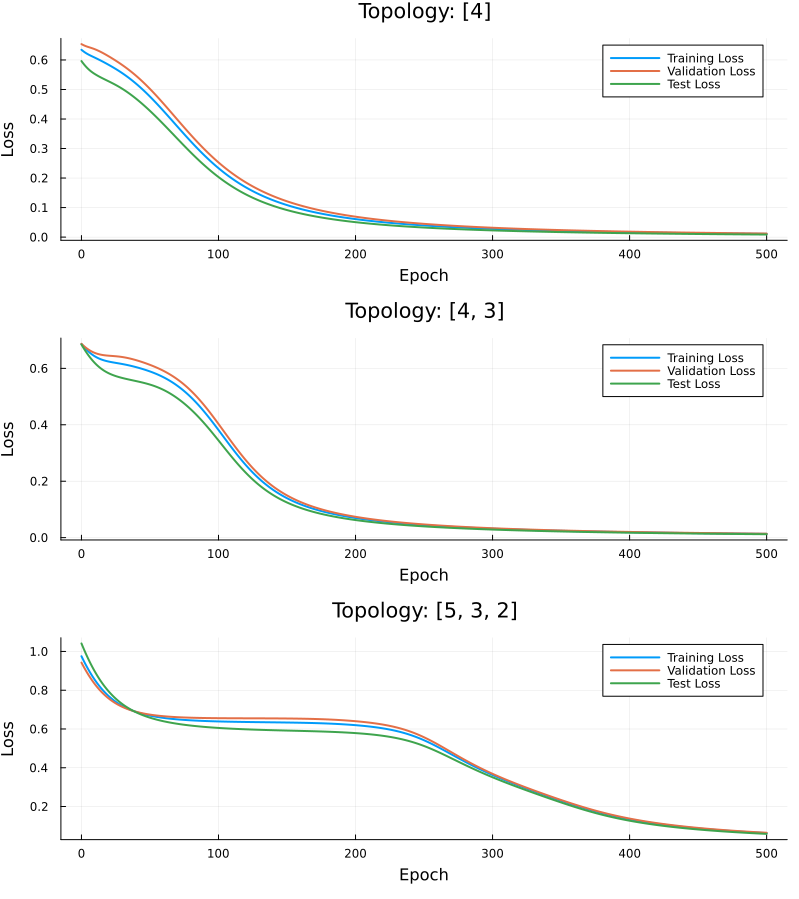


Pipeline completed!


In [56]:
# ============================================
# COMPLETE PIPELINE WITH NORMALIZATION AND PLOTS
# ============================================

using Plots

# 1. Load database (already done above)
println("Step 1: Database loaded")

# 2. Split data using holdOut
N = size(features, 1)
Pval = 0.2
Ptest = 0.1

train_idx, val_idx, test_idx = holdOut(N, Pval, Ptest)

train_inputs = features[train_idx, :]
train_targets = reshape(labels_bool[train_idx], :, 1)

val_inputs = features[val_idx, :]
val_targets = reshape(labels_bool[val_idx], :, 1)

test_inputs = features[test_idx, :]
test_targets = reshape(labels_bool[test_idx], :, 1)

println("Step 2: Data split into train/val/test")

# 3. Calculate normalization parameters from TRAINING SET ONLY
normParams = calculateMinMaxNormalizationParameters(train_inputs)
println("Step 3: Normalization parameters calculated from training set")

# 4. Normalize all three sets using the parameters from training
train_inputs_norm = normalizeMinMax(train_inputs, normParams)
val_inputs_norm = normalizeMinMax(val_inputs, normParams)
test_inputs_norm = normalizeMinMax(test_inputs, normParams)

println("Step 4: All sets normalized")

# 5. Train different architectures and plot results
println("\nStep 5: Training different architectures...")

topologies = [[4], [4, 3], [5, 3, 2]]
plots_array = []

for topology in topologies
    println("\n" * "="^60)
    println("Training topology: ", topology)
    println("="^60)
    
    ann, train_losses, val_losses, test_losses = trainClassANN(
        topology,
        (train_inputs_norm, train_targets),
        validationDataset=(val_inputs_norm, val_targets),
        testDataset=(test_inputs_norm, test_targets),
        maxEpochs=500,
        learningRate=0.01,
        maxEpochsVal=20,
        showText=false
    )
    
    println("Training completed: ", length(train_losses)-1, " epochs")
    println("Final - Train: ", round(train_losses[end], digits=4), 
            " Val: ", round(val_losses[end], digits=4),
            " Test: ", round(test_losses[end], digits=4))
    
    # Plot losses (including cycle 0)
    epochs = 0:length(train_losses)-1
    p = plot(epochs, train_losses, 
             label="Training Loss", 
             xlabel="Epoch", 
             ylabel="Loss", 
             title="Topology: $topology",
             legend=:topright,
             linewidth=2)
    plot!(p, epochs, val_losses, label="Validation Loss", linewidth=2)
    plot!(p, epochs, test_losses, label="Test Loss", linewidth=2)
    
    push!(plots_array, p)
end

# Display all plots together
final_plot = plot(plots_array..., layout=(3,1), size=(800, 900))
display(final_plot)

println("\nPipeline completed!")

### Question 3.2
> ❓ Has the test error always decreased or has there come a point where it has started to increase?

Based on the graphs generated using the Plots library support described at the end of  the notebook, I observe that the test loss generally decreased throughout training for all three topologies. For topology [4] and [4,3], the test loss decreased continuously 
without showing a significant increase. However, for topology [5,3,2], there appears to be a slight plateau and minor fluctuations in the later epochs, but no clear overfitting pattern where test loss increases significantly while training loss continues to decrease. Overall, the test error did not show the classic overfitting behavior of increasing after an initial decrease.

### Question 3.3
> ❓ How do the 3 precision values evolve?

According to the plots created with the Plots library, all three losses (training,  validation, and test) evolve similarly across the epochs. They start at high values (around 0.6-1.0 at epoch 0) and decrease rapidly in the first 100-200 epochs. The three loss curves remain very close to each other throughout training, which indicates good generalization. The final loss values for all three sets are very similar (within 0.001-0.005 of each other), suggesting that the model generalizes well to unseen data without overfitting to the training set.

### Question 3.4
> ❓ Which criteria usually stop the training? Why?

As observed in the experimental results and visualized in the graphs, the maxEpochs criterion stopped the training (all ran for 500 epochs). The early stopping criterion based on validation loss (maxEpochsVal=20) did not trigger because the validation loss continued to improve or remain stable throughout training. This suggests that the model was still learning and had not reached a point where validation performance degraded for 20 consecutive epochs. The minLoss criterion also did not trigger, as the losses remained above the threshold.

### Question 3.5
> ❓ To which cycle does the ANN returned by the function correspond? 

Since validation sets were provided and early stopping was configured, the ANN returned corresponds to the cycle with the best (lowest) validation loss achieved during training. This is implemented using the deepcopy mechanism in the trainClassANN function, which saves the model whenever validation loss improves. Even though training continued for all 500 epochs, the function returns the model from the epoch where validation loss was at its minimum, ensuring optimal generalization performance.

# Julia Notes

Julia has a library that allows you to display all kinds of plots in a very simple way.  To load it, simply put `using Plots`, the documentation can be found at http://docs.juliaplots.org/. As always the first should be to install, ifg it is not already installed:

In [35]:
using Pkg; Pkg.add("Plots")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


Actually, `Plots.jl` is not a package for displaying plots, but an interface to a set of libraries for displaying plots.  Plots.jl provides a set of functions that allow, in a unified way, to display plots using one or another library, with the same calls.  That is, what Plots.jl does is to interpret the commands and generate the plots using another graphics library, which it refers to as a backend. Therefore, it is possible to change the graphics library (backend) without having to modify the code, since the calls to the corresponding functions are the same for all backends. 

So, first of all, after loading `Plots`, is to select the backend you want to work with.  Julia provides a large number of widely used ones, which you have to install in the usual way if you want to use them. If you don't indicate which one you want to use, Julia defaults to choosing one depending on which ones are installed. To see which backend is being used, you can simply type `backend()`.

In [37]:
using Plots
backend()

Plots.GRBackend()

Some of the most common backends are: Plotly, PyPlot, PlotlyJS and GR. In general, to use a backend, you simply make a call to a function named after the backend itself, but in lowercase. For the 4 given as examples at the beginning of this paragraph, it would be with calls to `plotly()`, `pyplot()`, `plotlyjs()` and `gr()` respectively. As said before, in case it is not installed you will have to install it in the usual way, writing `Pkg.add("Plotly")`, `Pkg.add("PyPlot")`, `Pkg.add("PlotlyJS")` or `Pkg.add("GR")` respectively.   More information about the different backends can be found at https://docs.juliaplots.org/latest/backends/.

In [ ]:
# Install the pyplot and plotly if you do not have it

Once the desired backend is loaded, or with the default backend, you can start plotting. The easiest way is to use the plot function, which receives two parameters: the series to be put on the x-axis, and the series to be put on the y-axis, both as vectors, for example: 

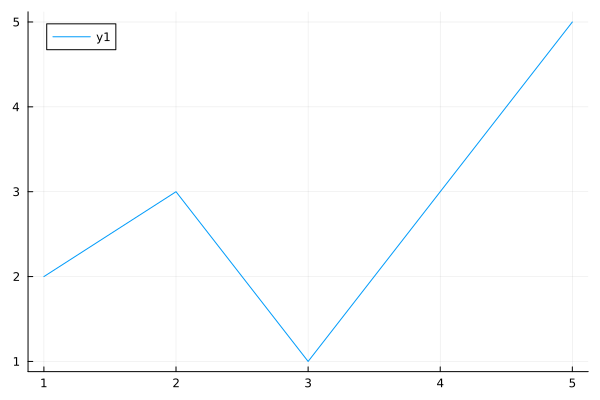

In [39]:
plot(1:5, [2, 3, 1, 3, 5])

In general, if you want to put more than one series on the graph, it is sufficient to specify one column per series in the matrix you pass to it for the y-axis data, for example:

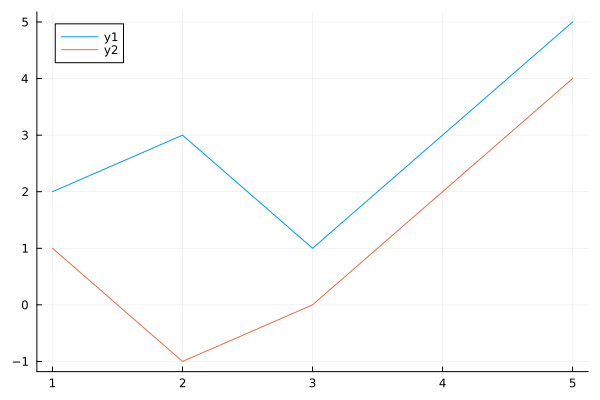

In [41]:
plot(1:5, [2 1; 3 -1; 1 0; 3 2; 5 4])

Another way to do this is to add more series to the plot object that has been created. That is, the call to plot returns an object that can be modified by further calls to `plot!` and passing it as the first parameter (remember that when the name of a function ends in `!` the argument passed is modified). The above example could be done in the following way: 

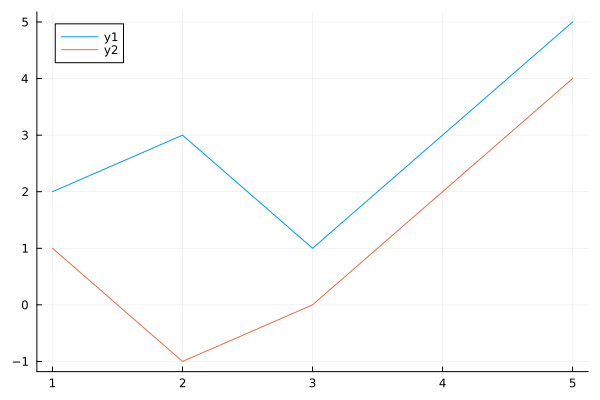

In [43]:
g = plot(1:5, [2, 3, 1, 3, 5]) 
plot!(g, 1:5, [1, -1, 0, 2, 4])

Or alternatively:

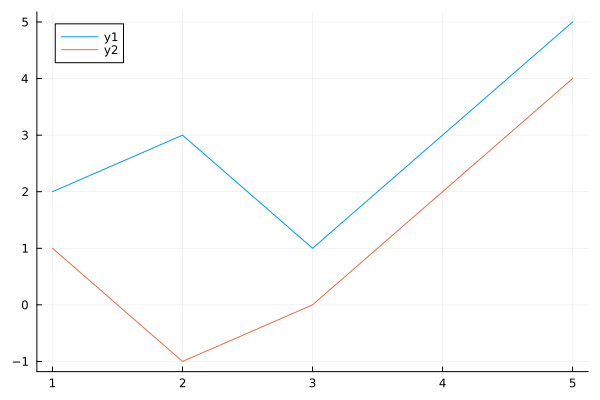

In [45]:
g = plot() 
plot!(g, 1:5, [2, 3, 1, 3, 5]) 
plot!(g, 1:5, [1, -1, 0, 2, 4])

For any of these three possibilities, if this is done in the command interpreter, the graph will appear.  In fact, in the second and third possibilities, more than one graph will appear as you create them. However, if this is done in a script, the graph does not automatically appear.  If we want it to appear, we have to make a call to display in this way: 

```julia
    display(g)
```

Besides the function plot, there are many other functions that allow you to represent other types of graphs and charts with the usual names, such as `heatmap`, `plot3d`, `scatter`, `histogram`, `boxplot`, `violin`, etc., all of them with their corresponding function ending in `!`.  As always, you can consult the help of a function by typing, for example: 

In [48]:
?boxplot

search: boxplot boxplot!



```
boxplot(x, y)
boxplot!(x, y)
```

Make a box and whisker plot.

# Keyword arguments

  * `notch`: Bool. Notch the box plot? (false)
  * `whisker_range`: Real. Whiskers extend `whisker_range`*IQR below the first quartile          and above the third quartile. Values outside this range are shown as outliers (1.5)
  * `outliers`: Bool. Show outliers? (true)
  * `whisker_width`: Real or Symbol. Length of whiskers; the options are `:match` to match the box width, `:half`, or a number to indicate the total length. (:half)

# Example

```julia-repl
julia> using StatsPlots
julia> boxplot(repeat([1,2,3],outer=100),randn(300))
```


Generally speaking, it is desired to add more information to the graphs than just the data used in the graph.  This information usually includes title, labels on the axes, legend, markers at each point, line type, colours, etc.  This is usually done through attributes passed as keywords in function calls, such as `axis`, `label`, `line`, `fill`, `marker`, `ticks`, `title`, `xlabel`, `ylabel`, for example: 

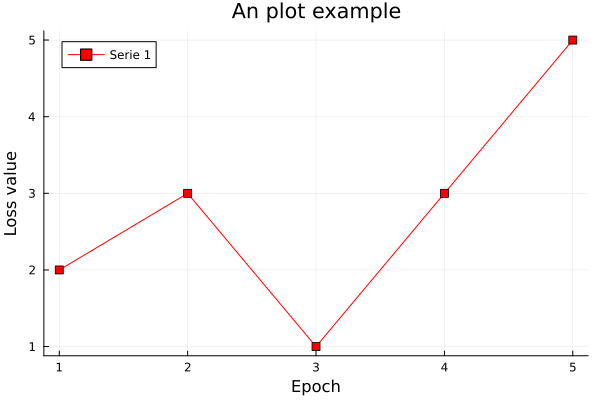

In [50]:
plot(1:5, [2, 3, 1, 3, 5], 
    xaxis = "Epoch", yaxis = "Loss value", title = "An plot example", 
    marker = :square, color = :red, label = "Serie 1")

A quick overview of the most common keywords can be found at https://docs.juliaplots.org/latest/attributes/.   On the other hand, https://docs.juliaplots.org/latest/generated/supported/tenéis has a complete list of the different types of series, keywords, markers, line styles and scales supported by each backend.  As you can see, the list of graphs and arguments is quite extensive, which gives you an idea of the enormous possibilities Julia offers when it comes to plotting graphs.

Another common issue when displaying graphs is to combine several graphs within a single window.  There are several methods to do this, the simplest and most commonly used being by using the keyword `layout` in the call to the corresponding function to generate the graph containing all of them.  In this sense, it is the easiest way to generate the graphs independently, and combine them later in a new call using the keyword `layout`, which receives as parameter a tuple with the number of rows and columns of the matrix of graphs, for example:

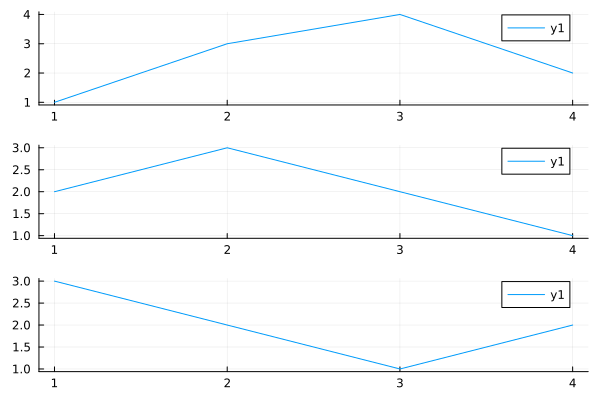

In [52]:
p1 = plot(1:4, [1, 3, 4, 2]); 
p2 = plot(1:4, [2, 3, 2, 1]); 
p3 = plot(1:4, [3, 2, 1, 2]); 
plot(p1, p2, p3, layout = (3,1))

As you could see, the plots asre arrange in a column layout each one in a row, alternatively, if we invert the order the result could be set in a single row as in:

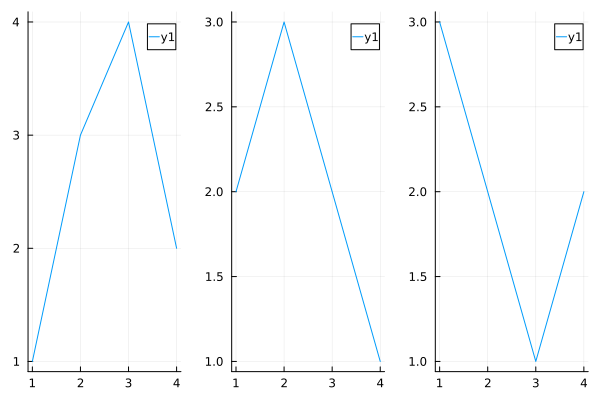

In [54]:
plot(p1, p2, p3, layout = (1,3))

More information on how to combine graphics can be found at https://docs.juliaplots.org/latest/layouts/. 

Finally, another very common action is to save the generated graphs.  This can be done by means of the savefig function, which receives as parameters the graph to save and the file name. From the extension indicated in the file name, Julia saves the graph in the indicated format. Some of the most typical formats are `pdf`, `png` or `ps`.  Although this is a very easy way to save the graphs, not all file types are supported by all backends. At https://docs.juliaplots.org/latest/output/ you can check the file formats supported by each backend. For exple with the previous example.

```julia
    g = plot(p1, p2, p3, layout = (1,3))
    savefig(g, 'ExampleSingleRow.png')
```